In [8]:
# load required packages for data exploration and visualization
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [9]:
# import train data
data = pd.read_csv('../data/train.csv')

# Exploratory Data Analysis

## Explore Data Characteristics

In [10]:
data.head()

,surveyid,village,survey_date,femaleres,age,married,children,hhsize,edu,hh_children,...,given_mpesa,amount_given_mpesa,received_mpesa,amount_received_mpesa,net_mpesa,saved_mpesa,amount_saved_mpesa,early_survey,depressed,day_of_week
0,926,91,23-Nov-61,1,28.0,1,4,6,10,0,...,0,0.0,0,0.000000,0.000000,1,0.000000,0,0,5
1,747,57,24-Oct-61,1,23.0,1,3,5,8,0,...,0,0.0,1,4.804611,4.804611,0,0.000000,0,1,3
2,1190,115,05-Oct-61,1,22.0,1,3,5,9,0,...,0,0.0,0,8.007685,8.007685,1,0.000000,0,0,5
3,1065,97,23-Sep-61,1,27.0,1,2,4,10,2,...,0,0.0,0,0.000000,0.000000,1,1.249199,0,0,0
4,806,42,12-Sep-61,0,59.0,0,4,6,10,4,...,0,0.0,0,0.000000,0.000000,0,0.000000,0,0,3


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 75 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   surveyid                 1143 non-null   int64  
 1   village                  1143 non-null   int64  
 2   survey_date              1143 non-null   object 
 3   femaleres                1143 non-null   int64  
 4   age                      1143 non-null   float64
 5   married                  1143 non-null   int64  
 6   children                 1143 non-null   int64  
 7   hhsize                   1143 non-null   int64  
 8   edu                      1143 non-null   int64  
 9   hh_children              1143 non-null   int64  
 10  hh_totalmembers          809 non-null    float64
 11  cons_nondurable          1143 non-null   float64
 12  asset_livestock          1143 non-null   float64
 13  asset_durable            1143 non-null   float64
 14  asset_phone             

In [12]:
# Shape of the data
data.shape

(1143, 75)

In [13]:
data.describe()

,surveyid,village,femaleres,age,married,children,hhsize,edu,hh_children,hh_totalmembers,...,given_mpesa,amount_given_mpesa,received_mpesa,amount_received_mpesa,net_mpesa,saved_mpesa,amount_saved_mpesa,early_survey,depressed,day_of_week
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,809.000000,...,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,715.927384,76.409449,0.916885,34.537270,0.772528,2.860017,4.869641,8.735783,2.018373,4.906057,...,0.015748,0.553462,0.066492,3.564576,3.011114,0.188976,2.269096,0.097988,0.168854,3.295713
std,415.694525,66.788138,0.276176,13.742107,0.419383,1.846946,2.121852,2.867202,2.016702,2.099287,...,0.124554,6.489140,0.249249,24.950902,25.840639,0.391661,19.676268,0.297428,0.374787,1.684910
min,1.000000,1.000000,0.000000,17.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,-160.153700,0.000000,0.000000,0.000000,0.000000,0.000000
25%,351.500000,23.000000,1.000000,24.000000,1.000000,2.000000,3.000000,8.000000,0.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,717.000000,57.000000,1.000000,30.000000,1.000000,3.000000,5.000000,9.000000,2.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
75%,1078.500000,105.500000,1.000000,41.000000,1.000000,4.000000,6.000000,10.000000,3.000000,6.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
max,1429.000000,292.000000,1.000000,91.000000,1.000000,10.000000,12.000000,19.000000,10.000000,12.000000,...,1.000000,160.153700,1.000000,352.338130,352.338130,1.000000,488.468780,1.000000,1.000000,6.000000


In [15]:
# drop survey id , locatin and date values
data.drop(['surveyid', 'village', 'survey_date'], axis=1, inplace=True, errors='ignore')

## Demographic Characteristics of Respondents

In [20]:
import tableone
from tableone import TableOne

# define respondet demographics
demographics_vars = [
    "femaleres",
    "age",
    "married",
    "children",
    "hhsize",
    "edu",
    "hh_children",
    "hh_totalmembers"
]

# define categorical variables
categorical_vars = [
    "femaleres",
    "married"
]

table = TableOne(
    data,
    columns=demographics_vars,
    categorical=categorical_vars
)

print(table.tabulate(tablefmt="fancy_grid"))

╒════════════════════════════╤════╤═══════════╤═════════════╕
│                            │    │   Missing │ Overall     │
╞════════════════════════════╪════╪═══════════╪═════════════╡
│ n                          │    │           │ 1143        │
├────────────────────────────┼────┼───────────┼─────────────┤
│ femaleres, n (%)           │  0 │           │ 95 (8.3)    │
├────────────────────────────┼────┼───────────┼─────────────┤
│                            │  1 │           │ 1048 (91.7) │
├────────────────────────────┼────┼───────────┼─────────────┤
│ age, mean (SD)             │    │         0 │ 34.5 (13.7) │
├────────────────────────────┼────┼───────────┼─────────────┤
│ married, n (%)             │  0 │           │ 260 (22.7)  │
├────────────────────────────┼────┼───────────┼─────────────┤
│                            │  1 │           │ 883 (77.3)  │
├────────────────────────────┼────┼───────────┼─────────────┤
│ children, mean (SD)        │    │         0 │ 2.9 (1.8)   │
├───────

In [21]:
# stratify by depression status
table = TableOne(
    data,
    columns=demographics_vars,
    categorical=categorical_vars,
    groupby="depressed"
)

print(table.tabulate(tablefmt="fancy_grid"))

╒════════════════════════════╤════╤═══════════╤═════════════╤═════════════╤═════════════╕
│                            │    │   Missing │ Overall     │ 0           │ 1           │
╞════════════════════════════╪════╪═══════════╪═════════════╪═════════════╪═════════════╡
│ n                          │    │           │ 1143        │ 950         │ 193         │
├────────────────────────────┼────┼───────────┼─────────────┼─────────────┼─────────────┤
│ femaleres, n (%)           │  0 │           │ 95 (8.3)    │ 78 (8.2)    │ 17 (8.8)    │
├────────────────────────────┼────┼───────────┼─────────────┼─────────────┼─────────────┤
│                            │  1 │           │ 1048 (91.7) │ 872 (91.8)  │ 176 (91.2)  │
├────────────────────────────┼────┼───────────┼─────────────┼─────────────┼─────────────┤
│ age, mean (SD)             │    │         0 │ 34.5 (13.7) │ 33.9 (13.2) │ 37.6 (15.7) │
├────────────────────────────┼────┼───────────┼─────────────┼─────────────┼─────────────┤
│ married,

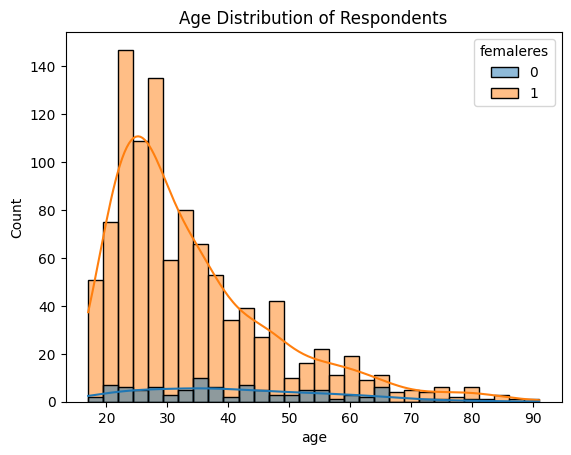

In [25]:
# distribution of age

sns.histplot(data = data, x = "age", bins=30, kde=True, hue="femaleres")
plt.title("Age Distribution of Respondents")
plt.show()

C:\Users\Ian Leboo\AppData\Local\Temp\ipykernel_34548\4239133835.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_gender = data.groupby(['age_group', 'femaleres']).size().unstack(fill_value=0)


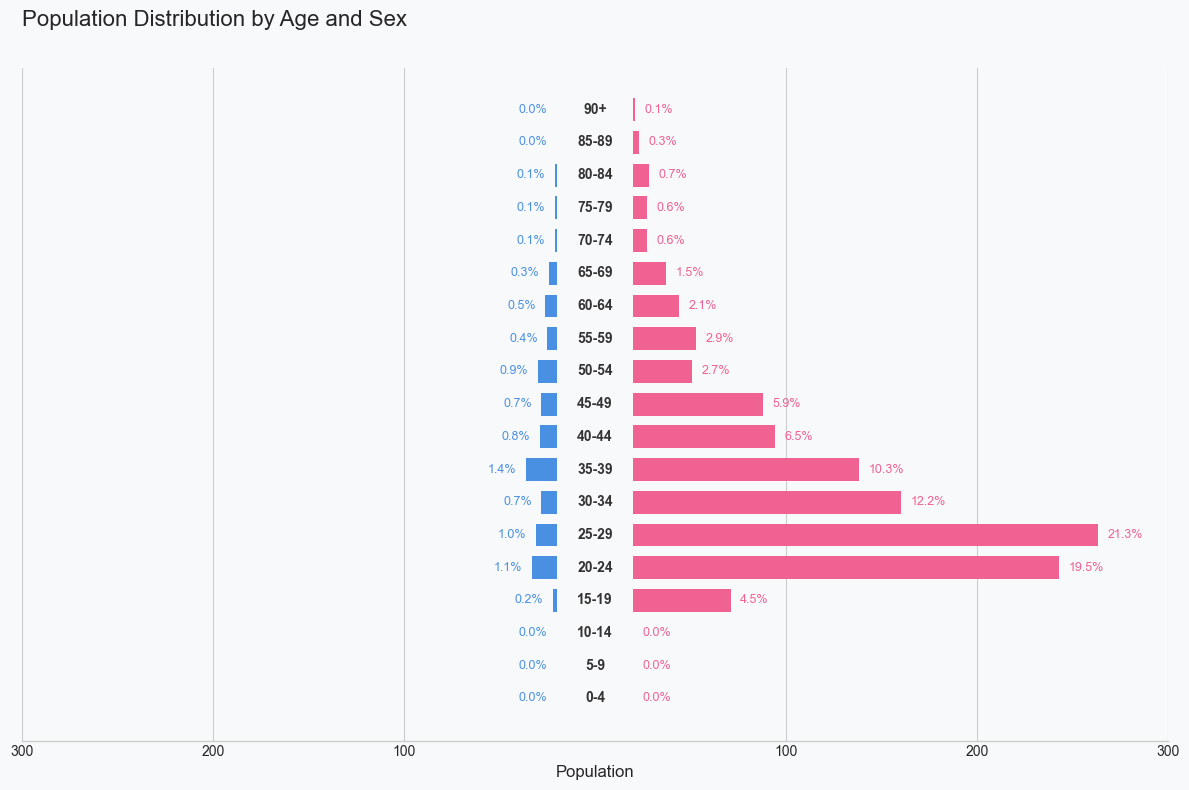

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare Data (assuming 'data' exists)
bins = list(range(0, 91, 5)) + [100]
labels = [f'{i}-{i+4}' for i in range(0, 86, 5)] + ['90+']
data['age_group'] = pd.cut(data['age'], bins=bins, labels=labels, right=False)

# Group by age group and gender (0=Male, 1=Female)
age_gender = data.groupby(['age_group', 'femaleres']).size().unstack(fill_value=0)

# Calculate Percentages
total_pop = age_gender.values.sum()
age_gender_pct = (age_gender / total_pop) * 100

# 2. Setup Plot
fig, ax = plt.subplots(figsize=(12, 8), facecolor='#f8f9fa')
ax.set_facecolor('#f8f9fa')

y = range(len(age_gender))
males = age_gender[0]
females = age_gender[1]
m_pct = age_gender_pct[0]
f_pct = age_gender_pct[1]

# 3. Draw Bars
# We use a gap in the middle for the labels by shifting bars left/right
offset = 20  # Space for the center labels
ax.barh(y, -males, color='#4A90E2', label='Male', height=0.7, left=-offset)
ax.barh(y, females, color='#F06292', label='Female', height=0.7, left=offset)

# 4. Add Age Group Labels in the center
for i, label in enumerate(age_gender.index):
    ax.text(0, i, label, ha='center', va='center', fontsize=10, fontweight='bold', color='#333')

# 5. Add Percentage Annotations
for i, (m, f, mp, fp) in enumerate(zip(males, females, m_pct, f_pct)):
    # Male percentages (left)
    ax.text(-m - offset - 5, i, f'{mp:.1f}%', ha='right', va='center', color='#4A90E2', fontsize=9)
    # Female percentages (right)
    ax.text(f + offset + 5, i, f'{fp:.1f}%', ha='left', va='center', color='#F06292', fontsize=9)

# 6. Styling
ax.set_title("Population Distribution by Age and Sex", fontsize=16, pad=30, loc='left')
ax.set_xlabel("Population", fontsize=12)

# Format X-axis to show positive numbers and hide the 0 center
ax.set_xticks([-300, -200, -100, 100, 200, 300])
ax.set_xticklabels(['300', '200', '100', '100', '200', '300'])

# Clean up chart borders
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.get_yaxis().set_visible(False) # Hide default y-axis

plt.tight_layout()
plt.show()



## Household Economics: Assets & Consumption (by Depression Status)

We examine asset ownership/value and consumption/expenditure patterns, stratified by depression status (`depressed`).
Most expenditure variables are right-skewed (USD amounts), so we use boxplots on a log1p scale alongside TableOne summaries.


In [ ]:
# Define variable groups for household economics

assets_vars = [
    "asset_livestock",
    "asset_durable",
    "asset_phone",
    "asset_savings",
    "asset_land_owned_total",
    "asset_niceroof",
    "durable_investment",
    "nondurable_investment"
]

assets_categorical = ["asset_niceroof"]

consumption_vars = [
    "cons_nondurable",
    "cons_allfood",
    "cons_ownfood",
    "cons_alcohol",
    "cons_tobacco",
    "cons_med_total",
    "cons_med_children",
    "cons_ed",
    "cons_social",
    "cons_other"
]

In [ ]:
# Assets - TableOne stratified by depression status

table_assets = TableOne(
    data,
    columns=assets_vars,
    categorical=assets_categorical,
    groupby="depressed",
    pval=True
)

print(table_assets.tabulate(tablefmt="fancy_grid"))

In [ ]:
# Consumption / Expenditure - TableOne stratified by depression status

table_consumption = TableOne(
    data,
    columns=consumption_vars,
    groupby="depressed",
    pval=True
)

print(table_consumption.tabulate(tablefmt="fancy_grid"))

In [ ]:
# Boxplots: continuous asset variables (log1p scale) by depression status

assets_continuous = [v for v in assets_vars if v not in assets_categorical]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(assets_continuous):
    sns.boxplot(data=data, x="depressed", y=np.log1p(data[col].clip(lower=0)), ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("log1p(value)")
    axes[i].set_xlabel("Depressed")

plt.suptitle("Asset Values by Depression Status (log scale)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Boxplots: consumption / expenditure variables (log1p scale) by depression status

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(consumption_vars):
    sns.boxplot(data=data, x="depressed", y=np.log1p(data[col].clip(lower=0)), ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("log1p(value)")
    axes[i].set_xlabel("Depressed")

plt.suptitle("Consumption & Expenditure by Depression Status (log scale)", fontsize=14)
plt.tight_layout()
plt.show()